In [2]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import numpy as np 
import h5ify 
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import importlib
import json

import sys
sys.path.append('/home/kgk3/tdinf/tdinf/')
from tdinf import group_postprocess, utils, run_sampler

importlib.reload(group_postprocess)
importlib.reload(run_sampler)

<module 'tdinf.run_sampler' from '/home/kgk3/tdinf/tdinf/run_sampler.py'>

### Load likelihood manager

In [3]:
 # Get likelihood manager
# run = 'output'
# data = group_postprocess.load_run_settings_from_directory(
#     'output/'+run,
data = group_postprocess.load_run_settings_from_directory('output/',
    filename_dict={'full':'full_0.0seconds'}
)
lm = data['runs']['full']['likelihood_manager']

FileNotFoundError: [Errno 2] No such file or directory: 'output/tasks_run.txt'

### Plot PSD

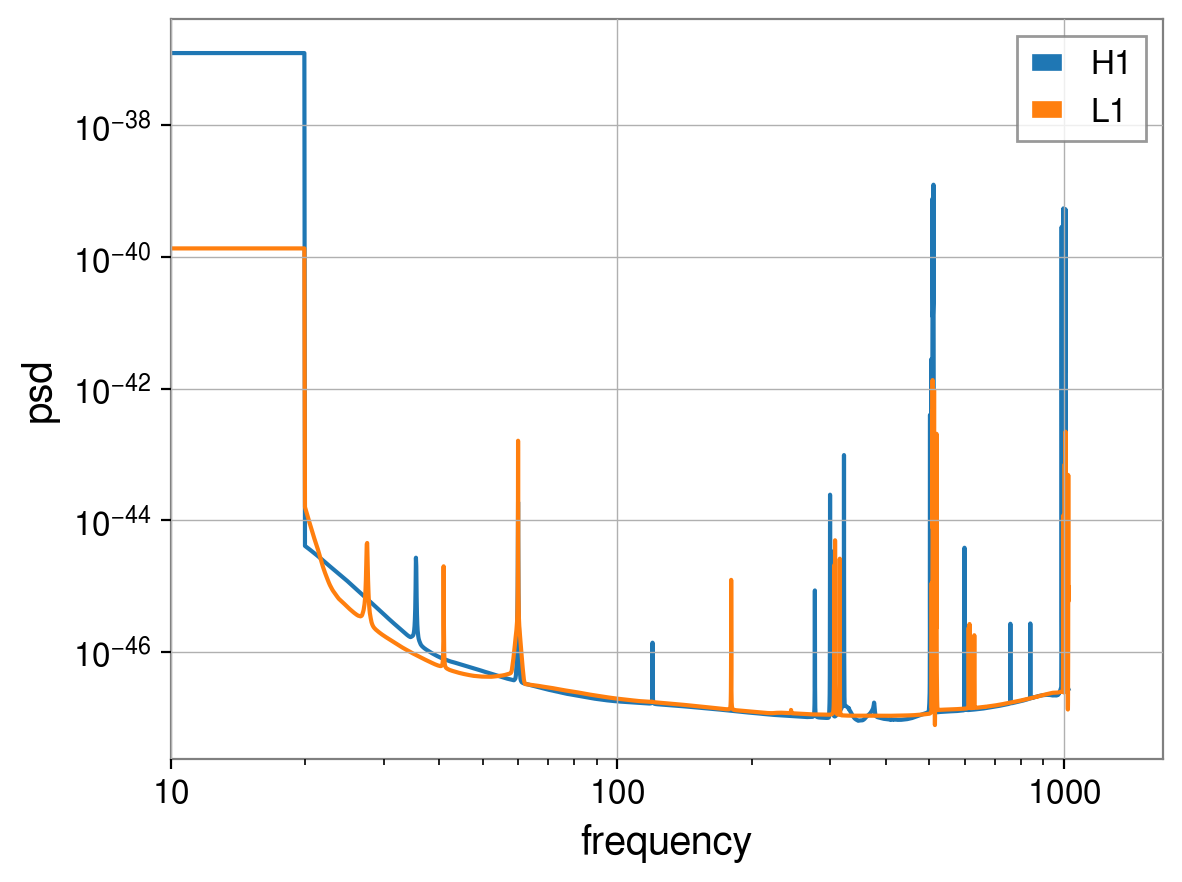

In [4]:
# Plot conditioned PSD
plt.figure()
for i, ifo in enumerate(lm.ifos): 
    freq, psd = lm.conditioned_psd_dict[ifo].transpose()
    plt.loglog(freq, psd, color=f'C{i}', label=ifo)
plt.xlabel('frequency')
plt.ylabel('psd')
plt.legend()
plt.xlim(10,)
plt.show()

### Plot ACF

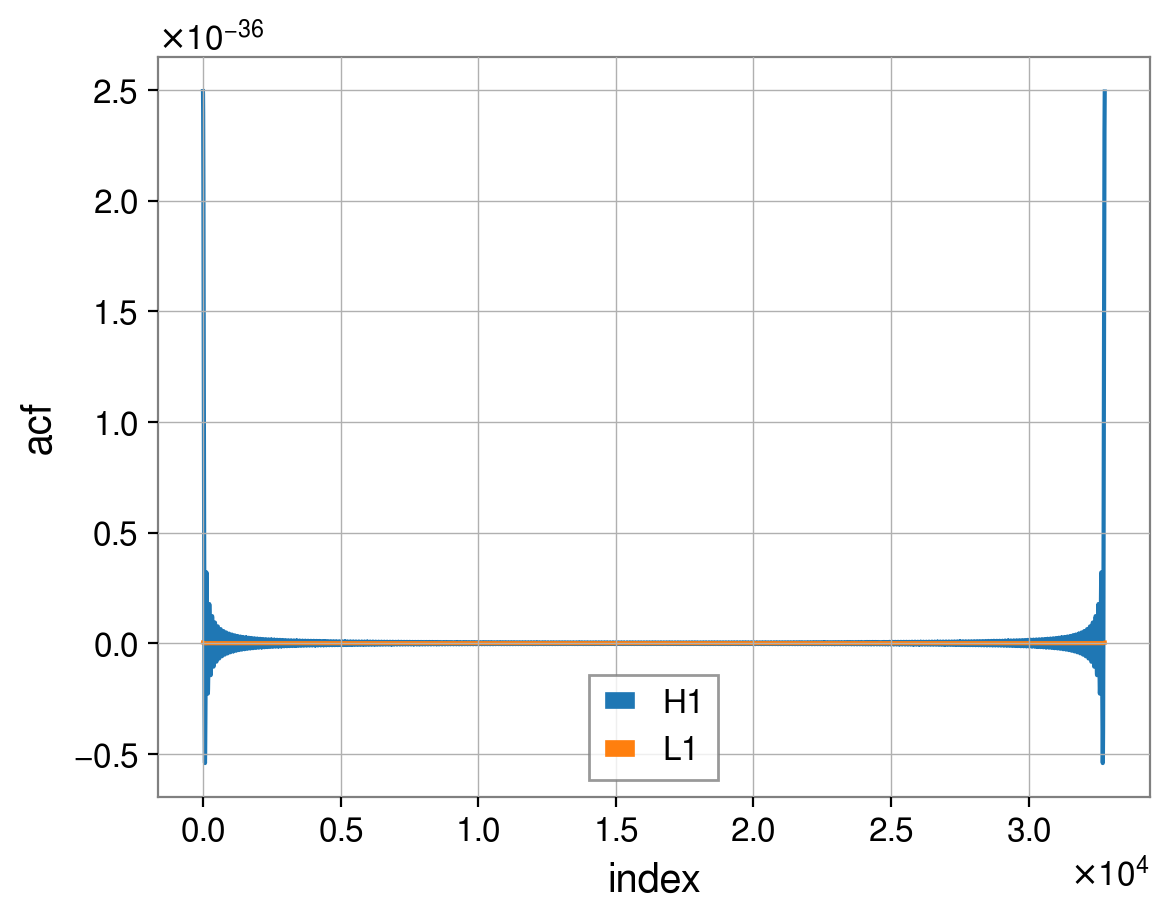

In [5]:
# Plot conditioned PSD
plt.figure()
for i, ifo in enumerate(lm.ifos): 
    acf = lm.rho_dict[ifo]
    plt.plot(acf, color=f'C{i}', label=ifo)
plt.xlabel('index')
plt.ylabel('acf')
plt.legend()
plt.show()

### Load FD posterior and get maxL reconstruction

In [23]:
# get reference parameters
FD_posterior = h5ify.load('GW241110_input_data/GW241110_124123-combined_PEDataRelease.h5')['C00:SEOBNRv5PHM']['posterior_samples']

# get maxL
imax = np.argmax(FD_posterior['log_likelihood'])
reference_parameters_ = FD_posterior[imax]
reference_parameters = {k: reference_parameters_[k] for k in reference_parameters_.dtype.names}

In [30]:
print(lm.f22_start)

20.0


In [31]:
# Get injection
reference_parameters_transformed = run_sampler.modify_parameters(reference_parameters, data['runs']['full']['args'])
injection_dict = lm.waveform_manager.get_projected_waveform(
    reference_parameters_transformed,
    lm.ifos,
    lm.time_dict,
    10, #lm.f22_start, 
    lm.f_ref
)
# Whiten injection
injection_dict_whitened = {ifo : utils.whitenData(
    injection_dict[ifo], 
    lm.time_dict[ifo],
    lm.conditioned_psd_dict[ifo][:, 1], 
    lm.conditioned_psd_dict[ifo][:, 0]
) for ifo in lm.ifos}

### Plot strain

In [32]:
# Get detector delay times 
dt_dict = lm.waveform_manager.antenna_and_time_manager.compute_time_delay_dict(
    data['runs']['full']['kwargs']['right_ascension'], 
    data['runs']['full']['kwargs']['declination'], 
    lm.reference_time, 
    lm.ifos
)

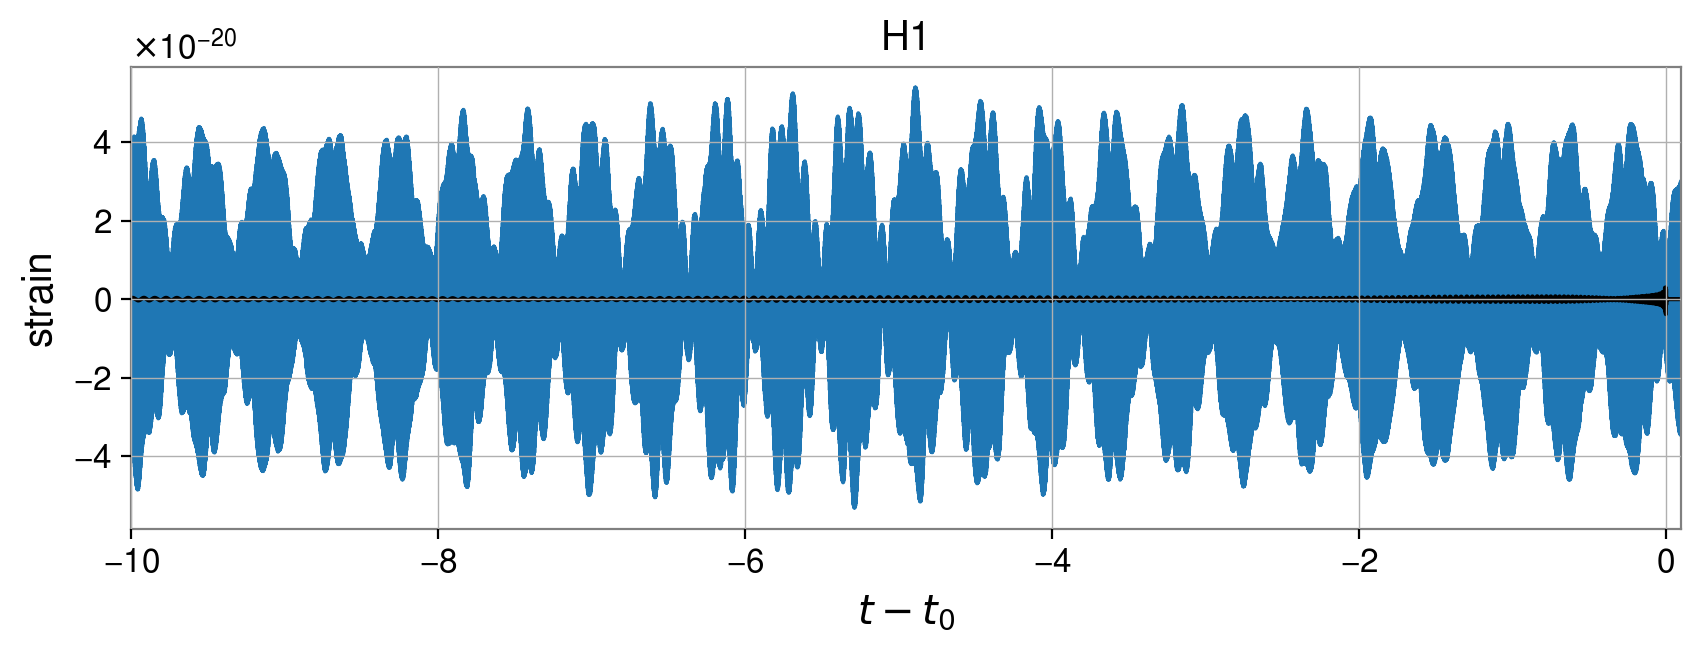

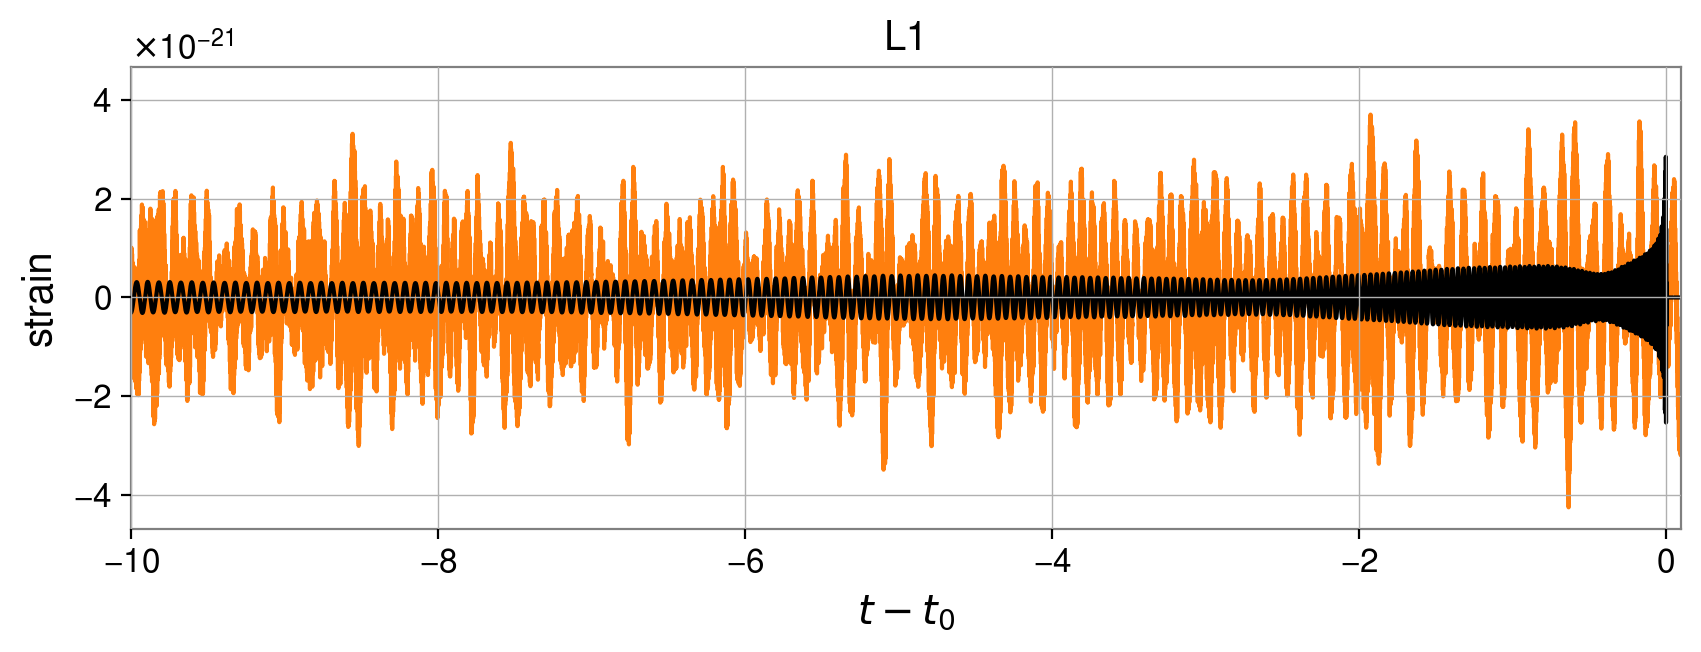

In [34]:
# Colored strain 
for i, ifo in enumerate(lm.ifos): 

    times = lm.time_dict[ifo] - lm.reference_time - dt_dict[ifo]

    plt.figure(figsize=(10, 3))
    plt.plot(times, lm.data_dict[ifo], color=f'C{i}')
    plt.plot(times, injection_dict[ifo]*20, color='k')
    plt.title(ifo)
    plt.xlim(-10, 0.1)
    plt.xlabel('$t - t_0$')
    plt.ylabel('strain')
    plt.show()

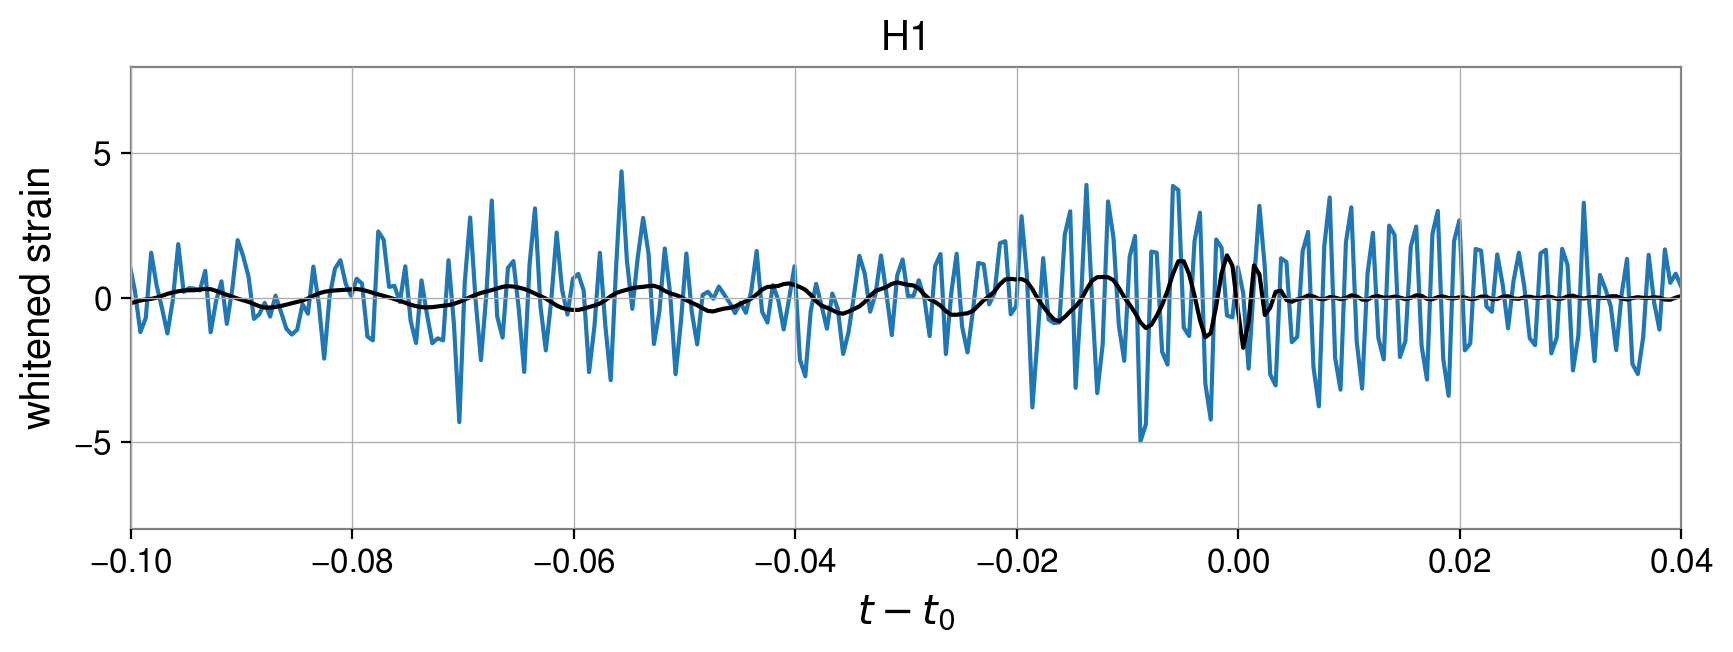

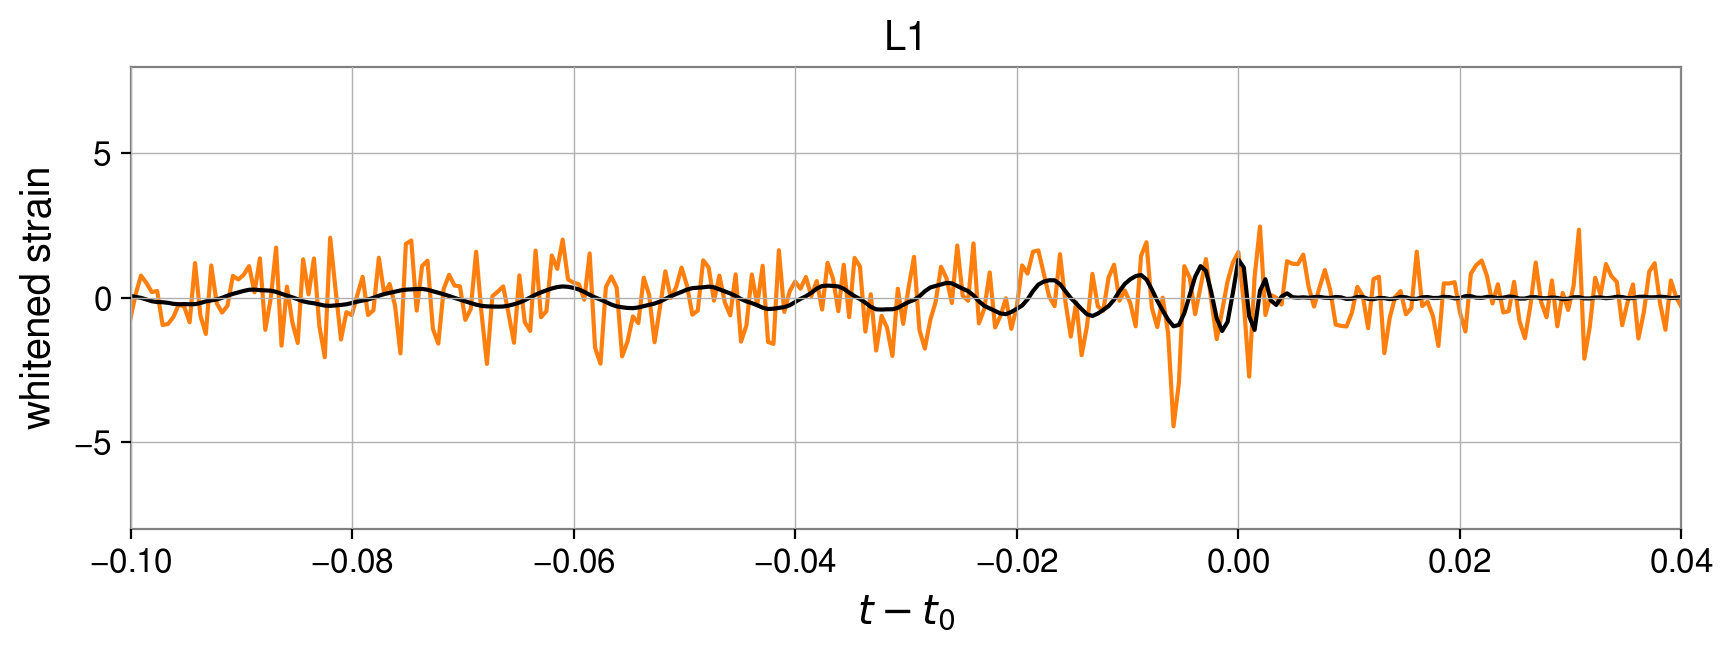

In [35]:
# Whitened strain cropped
for i, ifo in enumerate(lm.ifos): 

    times = lm.time_dict[ifo] - lm.reference_time - dt_dict[ifo]

    plt.figure(figsize=(10, 3))
    plt.plot(times, lm.whitened_data_dict[ifo], color=f'C{i}')
    plt.plot(times, injection_dict_whitened[ifo], color='k')
    plt.title(ifo)
    plt.xlabel('$t - t_0$')
    plt.ylabel('whitened strain')
    plt.xlim(-0.1, 0.04)
    plt.ylim(-8,8)
    plt.show()

### Cumulative SNR check

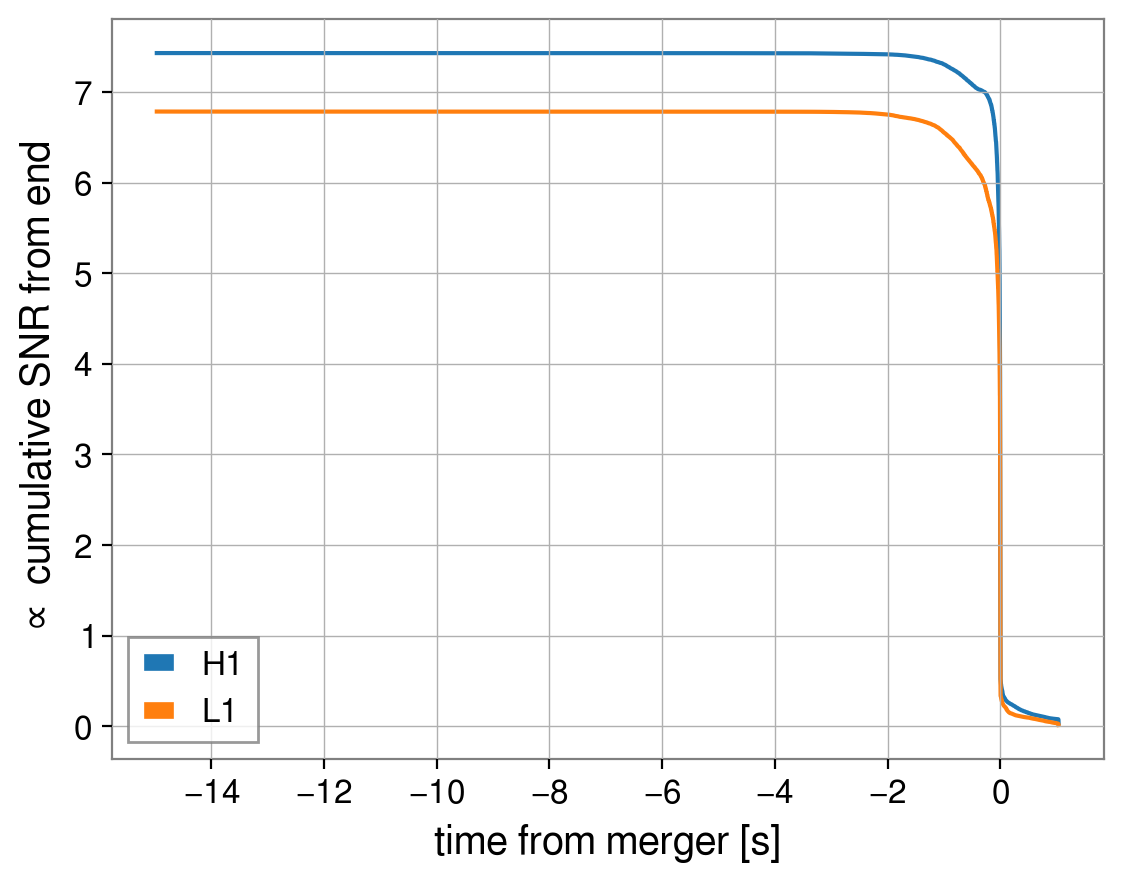

In [36]:
plt.plot()
for ifo in lm.ifos:
    
    times_det = lm.time_dict[ifo] - lm.reference_time - dt_dict[ifo]
    cum_snr = np.sqrt(np.cumsum(injection_dict_whitened[ifo][::-1]**2))
    
    plt.plot(times_det[::-1], cum_snr, label=ifo)
    
plt.legend()
plt.ylabel('$\propto$ cumulative SNR from end')
plt.xlabel('time from merger [s]')
plt.show()

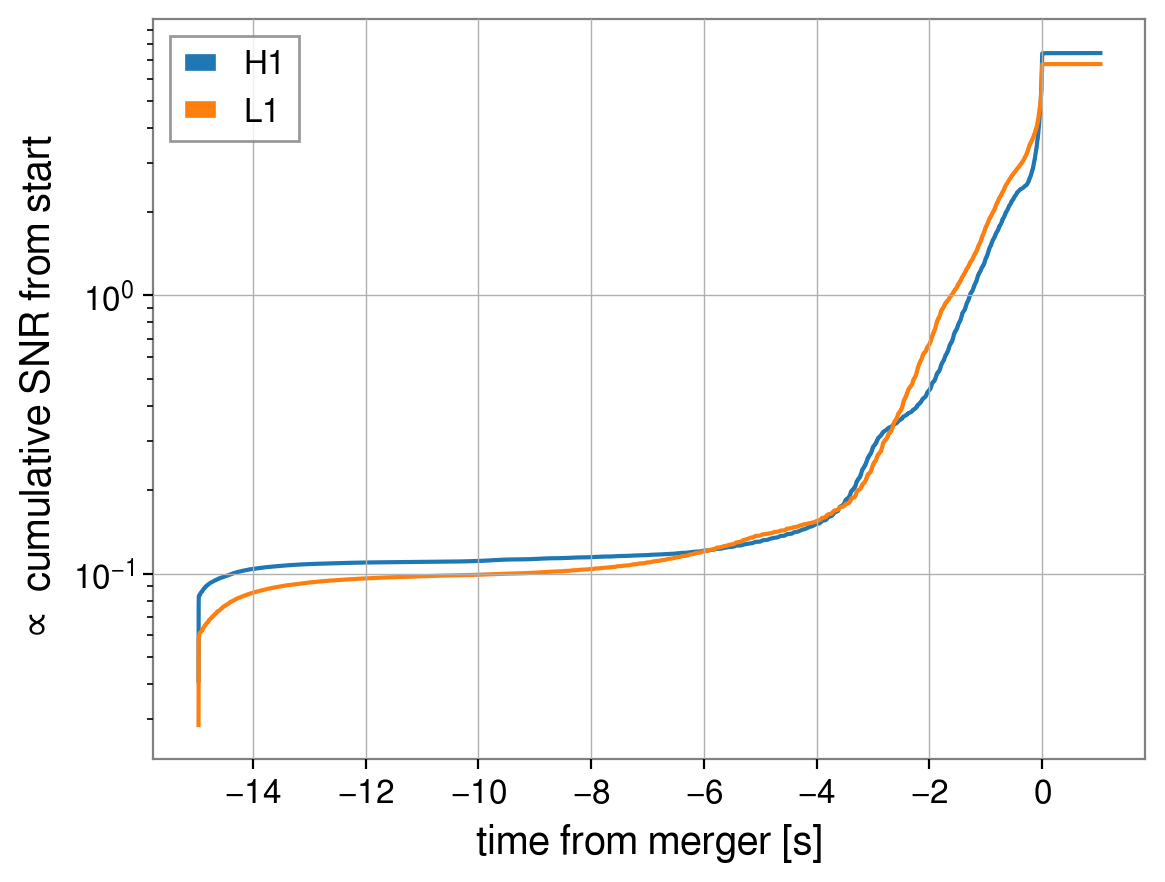

In [38]:
plt.plot()
for ifo in lm.ifos:
    
    times_det = lm.time_dict[ifo] - lm.reference_time - dt_dict[ifo]
    cum_snr = np.sqrt(np.cumsum(injection_dict_whitened[ifo]**2))
    
    plt.plot(times_det, cum_snr, label=ifo)

plt.yscale('log')
plt.legend()
plt.ylabel('$\propto$ cumulative SNR from start')
plt.xlabel('time from merger [s]')
plt.show()